# Outline
- Use Univariate and Multivariate Techniques to identify Outliers

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
houses = pd.read_csv('C:/Users/Wajih/Work (DataScience)/CAPSTONE PROJECTS/Real Estate Project/Zameen.com/EDA/houses.csv',index_col=0)
flats = pd.read_csv('C:/Users/Wajih/Work (DataScience)/CAPSTONE PROJECTS/Real Estate Project/Zameen.com/EDA/flats.csv',index_col=0)

In [3]:
houses.drop(columns=['Community Swimming Pool', 'Community Gym', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen','Lobby in Building', 'Elevators',
       'Service Elevators in Building'],inplace=True)

In [4]:
houses.info()

<class 'pandas.DataFrame'>
Index: 2080 entries, 0 to 2865
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   2080 non-null   str    
 1   Price(Cr)                              2080 non-null   float64
 2   Bath(s)                                2041 non-null   float64
 3   Area(Marla)                            2080 non-null   float64
 4   Bedroom(s)                             2049 non-null   float64
 5   Location                               2080 non-null   str    
 6   Description                            2080 non-null   str    
 7   Amenities: Main Features               1943 non-null   str    
 8   Amenities: Rooms                       1912 non-null   str    
 9   Amenities: Business and Communication  1831 non-null   str    
 10  Amenities: Community Features          1824 non-null   str    
 11  Amenities: Healthcar

In [5]:
flats.info()

<class 'pandas.DataFrame'>
Index: 730 entries, 16 to 2859
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   730 non-null    str    
 1   Price(Cr)                              730 non-null    float64
 2   Bath(s)                                721 non-null    float64
 3   Area(Marla)                            730 non-null    float64
 4   Bedroom(s)                             713 non-null    float64
 5   Location                               730 non-null    str    
 6   Description                            730 non-null    str    
 7   Amenities: Main Features               688 non-null    str    
 8   Amenities: Rooms                       658 non-null    str    
 9   Amenities: Business and Communication  633 non-null    str    
 10  Amenities: Community Features          637 non-null    str    
 11  Amenities: Healthcar

In [6]:
print('Houses Duplicated',houses.duplicated().sum())
print('Flats Duplicated',flats.duplicated().sum())

Houses Duplicated 0
Flats Duplicated 0


## Univariate Outlier Detection
- Z Score --> for Normal Distributions
- IQR --> for Non Normal Distributions

In [7]:
# Price

<Axes: ylabel='Price(Cr)'>

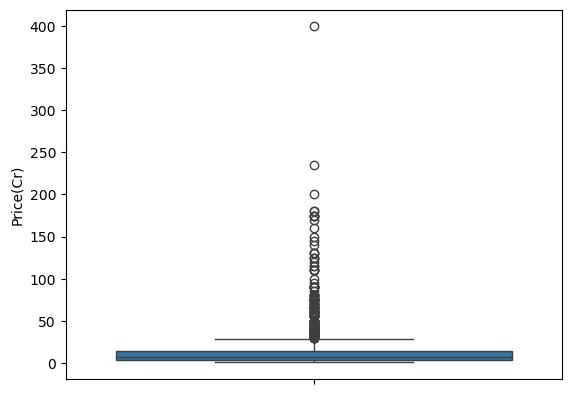

In [8]:
sns.boxplot(houses['Price(Cr)'])

In [9]:
# Analyzing the rows where Price > 150 Cr
houses[houses['Price(Cr)']>150]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Built in year,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit
289,House,235.0,6.0,78.0,9.0,F-6,F-6/3 Beautiful House 100 % Out of Market Deal...,"Built in year: 2023, Parking Spaces: 4, Double...","Bedrooms: 9, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,2023.0,4.0,3.0,9.0,10.0,3.0,2.0,2.0,1.0,NaN
292,House,175.0,6.0,80.0,8.0,F-8,F8 Almost Brand New House 4 Kanals Most Prime ...,"Built in year: 2025, Parking Spaces: 4, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 2...",NaN,...,2025.0,4.0,2.0,8.0,8.0,2.0,2.0,2.0,NaN,NaN
863,House,400.0,7.0,80.0,8.0,F-7,Marriott Estate And Builders Offer a Ideal Hou...,"Built in year: 20223, Parking Spaces: 7, Doubl...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,20223.0,7.0,1.0,6.0,7.0,2.0,2.0,1.0,1.0,NaN
1303,House,175.0,6.0,100.0,10.0,F-6,Details: 1. Size 90 x 250 : 2500 sqyrds. 2. Su...,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1564,House,170.0,7.0,80.0,7.0,F-7,"Offered by: Agency 9T9 99% Expertise, 1% Magic...","Built in year: 1990, Parking Spaces, Double Gl...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1990.0,1.0,3.0,7.0,7.0,2.0,2.0,1.0,NaN,NaN
1622,House,180.0,6.0,80.0,5.0,F-6,#Top Location #Hill Road #Corner #Extra land #...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,2025.0,2.0,1.0,5.0,6.0,1.0,2.0,1.0,NaN,NaN
1681,House,175.0,6.0,76.0,8.0,F-6,Details: 1. Size 1888 sqyrds. 2. off Margla Ro...,NaN,NaN,NaN,...,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1851,House,180.0,5.0,80.0,7.0,F-7,Marriott Estate And Builders Offer a Ideal Hou...,"Built in year: 2009, Parking Spaces: 7, Double...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2009.0,7.0,2.0,4.0,5.0,2.0,2.0,NaN,NaN,NaN
2052,House,175.0,7.0,80.0,7.0,F-7,Attached images are just for reference purpose...,"Built in year: 2000, Parking Spaces, Double Gl...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,2000.0,1.0,3.0,4.0,4.0,1.0,2.0,1.0,1.0,NaN
2279,House,160.0,6.0,82.0,6.0,F-6,Attached Images are for reference. Chohan HAY ...,"Parking Spaces, Flooring","Bedrooms: 6, Bathrooms: 6, Drawing Room, Dinin...",NaN,...,0.0,1.0,0.0,6.0,6.0,NaN,0.0,NaN,NaN,NaN


*F-6, F-7, F-8 all these are one of the most priced Locations, there are no outliers*

However, prices above 150 should be removed

In [10]:
houses = houses[~(houses['Price(Cr)']>=150)]

In [11]:
houses.shape

(2068, 28)

<Axes: ylabel='Price(Cr)'>

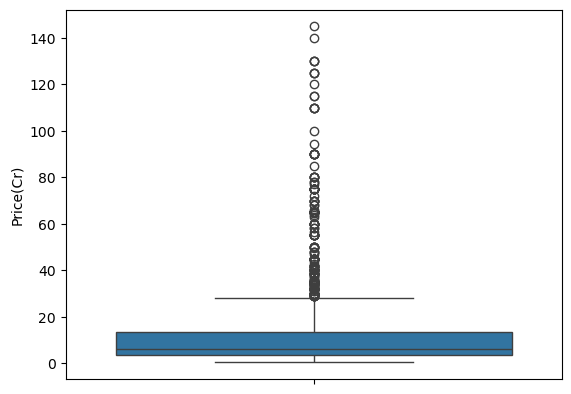

In [12]:
sns.boxplot(houses['Price(Cr)'])

In [13]:
# Area(Marla)

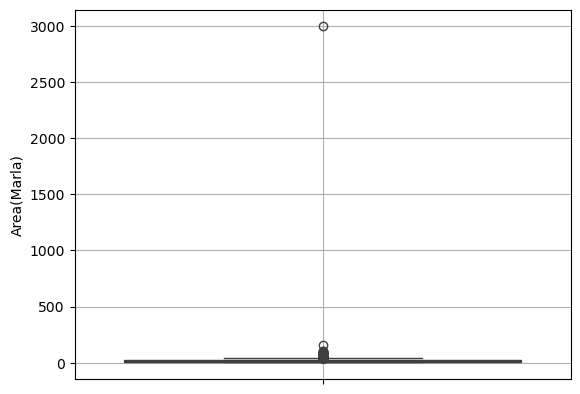

In [14]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

In [15]:
# Removind the Obvious Outlier
houses = houses[houses['Area(Marla)'] != houses['Area(Marla)'].max()]

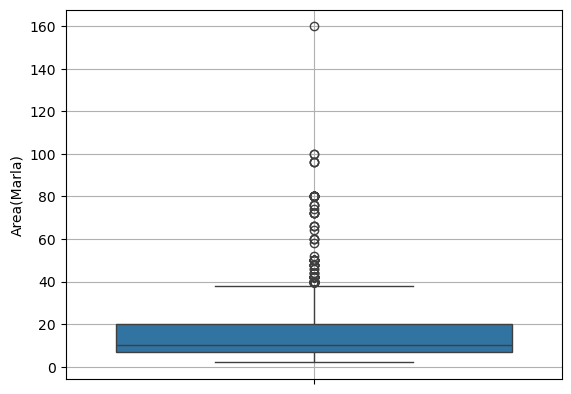

In [16]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

In [17]:
houses[houses['Area(Marla)']>80]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Built in year,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit
148,House,130.0,12.0,100.0,10.0,F-6,A beautiful house available for sale in f/6 co...,"Built in year: 2020, Parking Spaces: 8, Centra...","Bedrooms: 10, Bathrooms: 12, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,2020.0,8.0,2.0,10.0,12.0,3.0,2.0,1.0,NaN,NaN
791,House,35.0,7.0,100.0,8.0,Gulberg,Live Like the King You Are Meant to Be. Your P...,"Built in year: 2025, Parking Spaces: 8, Double...",NaN,"Broadband Internet Access, Satellite or Cable ...",...,2025.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1241,House,145.0,6.0,96.0,6.0,F-6,"Details; 1. Size 120 x 240 2. Front, side and ...","Built in year: 1970, Parking Spaces: 10, Doubl...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1970.0,10.0,2.0,6.0,7.0,2.0,2.0,1.0,1.0,1.0
1325,House,125.0,6.0,96.0,7.0,F-6,Details: 1. Size 120 x 240 : 2400 sqyrds. 2. A...,"Built in year: 1980, Parking Spaces: 10, Doubl...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1980.0,10.0,2.0,7.0,8.0,2.0,2.0,1.0,NaN,1.0
1574,House,130.0,6.0,96.0,10.0,F-6,Prime Location Prestigious Address in the Hear...,"Built in year: 2018, Parking Spaces, Double Gl...","Bedrooms: 10, Bathrooms: 10, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,2018.0,1.0,2.0,10.0,10.0,3.0,3.0,1.0,1.0,NaN
2818,House,65.0,6.0,160.0,7.0,Eighteen,The Villas Of Eighteen Are Designed For Those ...,"Built in year: 2024, Parking Spaces: 8, Double...","Bathrooms: 7, Servant Quarters, Drawing Room, ...","Broadband Internet Access, Satellite or Cable ...",...,2024.0,8.0,2.0,NaN,7.0,0.0,1.0,0.0,1.0,NaN


In [18]:
# Removing the rows where Area(Marla) > 80

houses = houses[~(houses['Area(Marla)']>80)]

<Axes: ylabel='Area(Marla)'>

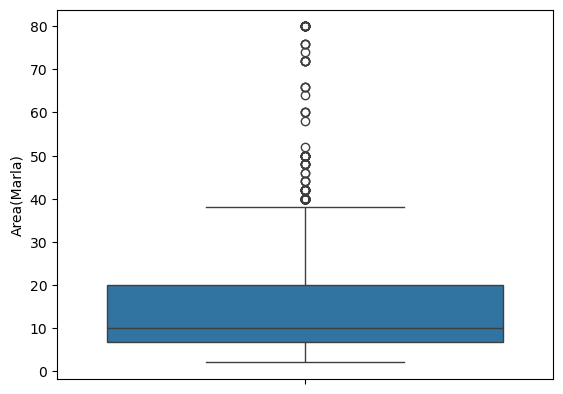

In [19]:
sns.boxplot(houses['Area(Marla)'])

In [20]:
# Bath(s)

<Axes: xlabel='Bath(s)', ylabel='count'>

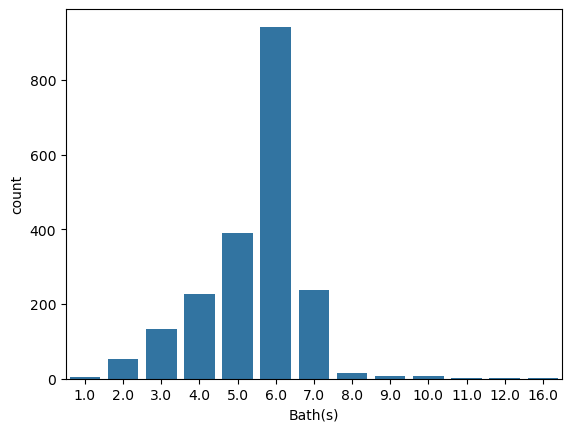

In [21]:
sns.barplot(houses['Bath(s)'].value_counts())

In [22]:
houses[houses['Bath(s)']>=8]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Built in year,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit
524,House,30.00,8.0,28.0,8.0,F-10,House For Sale In F10 Margalla Road 700 sqyrds...,"Built in year: 10, Parking Spaces: 6, Double G...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,10.0,6.0,1.0,8.0,8.0,2.0,2.0,2.0,1.0,NaN
532,House,6.65,9.0,20.0,7.0,Soan Garden,1 Kanal New Designer Double Story House is Ava...,"Built in year: 2024, Parking Spaces: 4, Double...","Bedrooms: 7, Bathrooms: 9, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,2024.0,4.0,2.0,7.0,9.0,1.0,2.0,1.0,1.0,2.0
619,House,10.50,10.0,14.0,9.0,Faisal Town - F-18,Project of TANVEER ASSOCIATES. Furnished House...,"Built in year: 2025, Parking Spaces: 3, Double...","Bedrooms: 9, Bathrooms: 10, Servant Quarters, ...","Broadband Internet Access, Satellite or Cable ...",...,2025.0,3.0,3.0,9.0,10.0,0.0,2.0,1.0,1.0,NaN
635,House,11.95,8.0,20.0,5.0,DHA Defence,1 Kanal Fully Furnished Luxury House for Sale ...,"Built in year: 2025, Parking Spaces: 3, Double...","Bedrooms: 5, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2025.0,3.0,0.0,5.0,8.0,2.0,2.0,2.0,1.0,NaN
777,House,42.50,10.0,42.0,4.0,F-7,Marriott Estate And Builders Offer a Ideal Hou...,"Built in year: 1990, Parking Spaces: 7, Double...","Bedrooms: 9, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,1990.0,7.0,2.0,9.0,10.0,3.0,2.0,0.0,1.0,NaN
778,House,65.00,8.0,36.0,6.0,F-8,Marriott Estate And Builders Offer a Ideal Hou...,"Built in year: 2018, Parking Spaces: 7, Double...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 3...","Broadband Internet Access, Satellite or Cable ...",...,2018.0,7.0,1.0,7.0,8.0,3.0,2.0,1.0,1.0,NaN
779,House,41.00,12.0,36.0,10.0,F-8,Marriott Estate And Builders Offer a Ideal Hou...,"Built in year: 2016, Parking Spaces: 10, Doubl...","Bedrooms: 10, Bathrooms: 12, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,2016.0,10.0,3.0,10.0,12.0,3.0,3.0,2.0,1.0,NaN
898,House,18.50,8.0,20.0,8.0,F-11,Prime location Corner house For Sale huge 8 be...,"Built in year: 2005, Parking Spaces: 8, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,2005.0,8.0,3.0,8.0,8.0,2.0,2.0,3.0,1.0,NaN
1067,House,65.00,9.0,36.0,9.0,F-8,Brand new house available for sale in f8 tripl...,"Built in year: 225, Parking Spaces: 7, Double ...","Bedrooms: 9, Bathrooms: 9, Servant Quarters: 3...","Broadband Internet Access, Satellite or Cable ...",...,225.0,7.0,3.0,9.0,9.0,3.0,2.0,2.0,1.0,3.0
1107,House,90.00,11.0,72.0,10.0,F-8,Experience luxury living at its finest with th...,"Built in year: 2024, Parking Spaces, Double Gl...","Bedrooms: 10, Bathrooms: 11, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,2024.0,1.0,2.0,10.0,11.0,2.0,2.0,2.0,1.0,NaN


<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

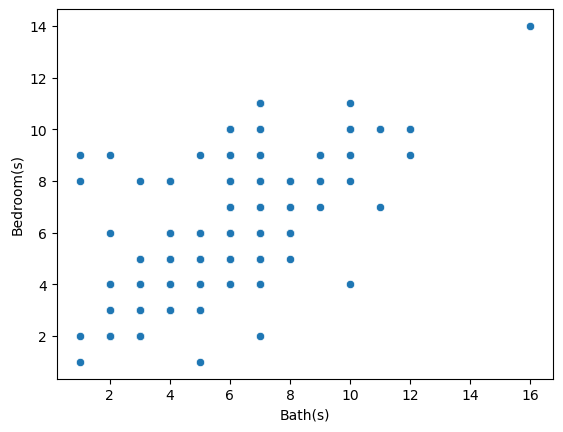

In [23]:
sns.scatterplot(x=houses['Bath(s)'],y=houses['Bedroom(s)'])

In [63]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms

from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=300,contamination = 0.005)
clf.fit(houses[['Bath(s)','Bedroom(s)']])
y_pred = clf.predict(houses[['Bath(s)','Bedroom(s)']])



<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

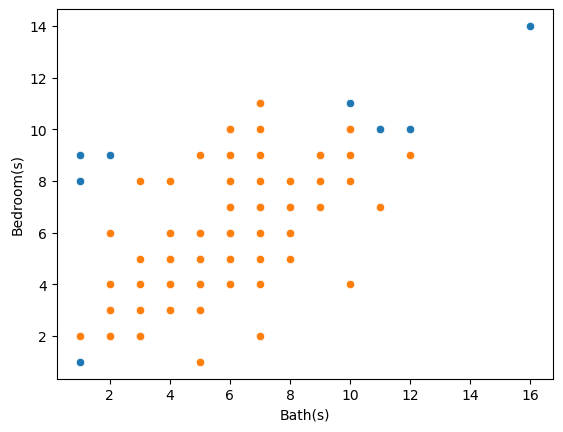

In [25]:
is_outlier = y_pred == -1

sns.scatterplot(x=houses.loc[is_outlier,'Bath(s)'],y=houses.loc[is_outlier,'Bedroom(s)'])

sns.scatterplot(x=houses.loc[~is_outlier,'Bath(s)'],y=houses.loc[~is_outlier,'Bedroom(s)'])

In [26]:
# Using LOF to determine outliers between Bathrooms and Bedrooms

temp_houses = houses.dropna(subset=['Bath(s)','Bedroom(s)'],how='any')

from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(contamination = 0.01)
y_pred = clf.fit_predict(temp_houses[['Bath(s)','Bedroom(s)']])



C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [27]:
houses[['Bath(s)','Bedroom(s)']].dropna().shape

(2022, 2)

<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

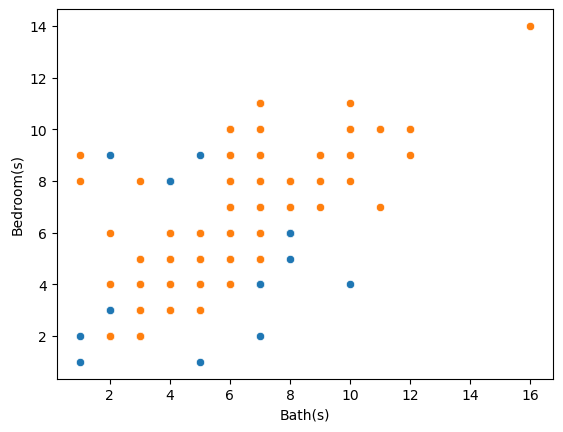

In [28]:
is_outlier = y_pred == -1

sns.scatterplot(x=temp_houses.loc[is_outlier,'Bath(s)'],y=temp_houses.loc[is_outlier,'Bedroom(s)'])

sns.scatterplot(x=temp_houses.loc[~is_outlier,'Bath(s)'],y=temp_houses.loc[~is_outlier,'Bedroom(s)'])

**The Mulitvariate Outlier Detection is not working as it should be, so the best way is to remove those rows where the difference between Bathrooms and Bedrooms is greater than 3**

In [29]:
houses['BedBath_Diff'] = houses['Bedroom(s)'] - houses['Bath(s)']

In [44]:
outlier_rows = houses[(houses['BedBath_Diff']>3)|(houses['BedBath_Diff']<-3)]

In [45]:
outlier_rows[['Bathrooms','Bedrooms']]

,Bathrooms,Bedrooms
147,5.0,5.0
262,10.0,8.0
290,12.0,10.0
365,4.0,4.0
366,10.0,9.0
630,12.0,10.0
686,11.0,10.0
693,6.0,6.0
777,10.0,9.0
874,4.0,3.0


In [60]:
houses.loc[777]

Type                                                                                 House
Price(Cr)                                                                             42.5
Bath(s)                                                                               10.0
Area(Marla)                                                                           42.0
Bedroom(s)                                                                             4.0
Location                                                                               F-7
Description                              Marriott Estate And Builders Offer a Ideal Hou...
Amenities: Main Features                 Built in year: 1990, Parking Spaces: 7, Double...
Amenities: Rooms                         Bedrooms: 9, Bathrooms: 10, Servant Quarters: ...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

In [ ]:
# No issue
290,

In [61]:
houses['Description'].loc[777]

'Marriott Estate And Builders Offer a Ideal House having following properties:- 1. Have 6 bedrooms with attached washrooms. 2. Two advanced kitchens. 3. Two T. V lounges, 4. Drawing room 5. Dining room, 6. Beautiful lawn 7. Terrace, 8. Servant rooms 9. Multiple car parkings 10. Installed air conditioners, 11. Central heating system 12. Water bore. We have also multiple options available for sale and rent in sectors F-6, F-7, F-8, E-7, G-6(3) F-10, F-11 Islamabad For further assistance please contact with us.'

<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

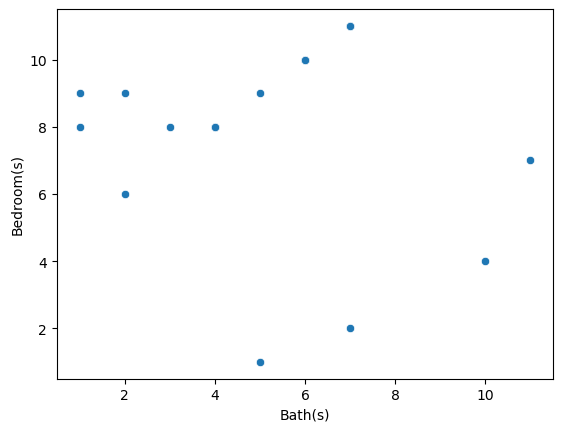

In [34]:
sns.scatterplot(data=houses[(houses['BedBath_Diff']>3)|(houses['BedBath_Diff']<-3)],x='Bath(s)',y='Bedroom(s)')

In [42]:
(houses['Floor']!=houses['Storey Unit']).index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2855, 2856, 2857, 2858, 2860, 2861, 2862, 2863, 2864, 2865],
      dtype='int64', length=2061)

In [43]:
houses.loc[0]

Type                                                                                 House
Price(Cr)                                                                             12.0
Bath(s)                                                                                7.0
Area(Marla)                                                                           10.0
Bedroom(s)                                                                             6.0
Location                                                                              D-12
Description                              10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...
Amenities: Main Features                 Built in year, Parking Spaces: 4, Double Glaze...
Amenities: Rooms                         Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

<Axes: xlabel='Bathrooms', ylabel='Bedrooms'>

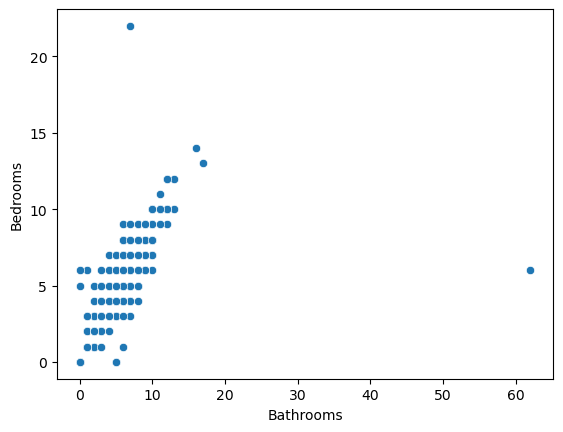

In [62]:
sns.scatterplot(x=houses['Bathrooms'],y=houses['Bedrooms'])

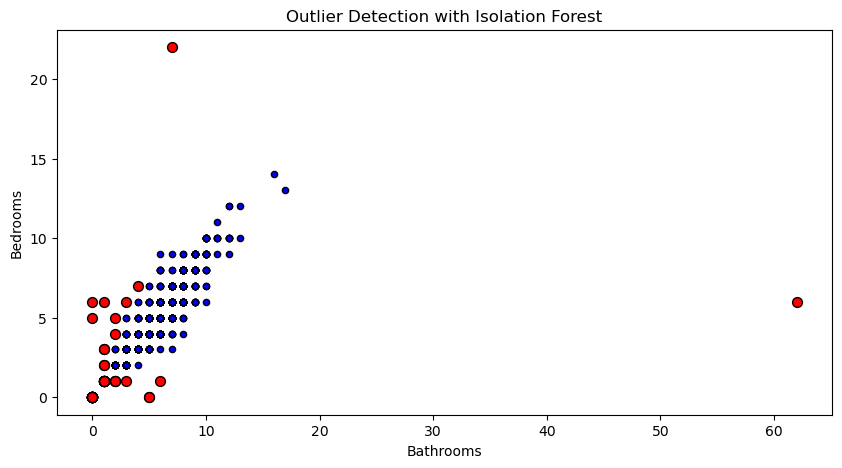

In [106]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms

from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=500,contamination = 0.03,random_state=42)
clf.fit(houses[['Bathrooms','Bedrooms']])
y_pred = clf.predict(houses[['Bathrooms','Bedrooms']])



plt.figure(figsize=(10, 5))
# Highlighting the outliers
is_outlier = y_pred == -1
plt.scatter(houses.loc[~is_outlier, 'Bathrooms'], houses.loc[~is_outlier, 'Bedrooms'], color='b', s=20, edgecolor='k')


plt.scatter(houses.loc[is_outlier, 'Bathrooms'], houses.loc[is_outlier, 'Bedrooms'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bathrooms")
plt.ylabel("Bedrooms")
plt.show()

In [92]:
# Using LOF to determine outliers between Bathrooms and Bedrooms

temp_houses = houses.dropna(subset=['Bathrooms','Bedrooms'],how='any')

from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(contamination = 0.06)
y_pred = clf.fit_predict(temp_houses[['Bathrooms','Bedrooms']])



C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


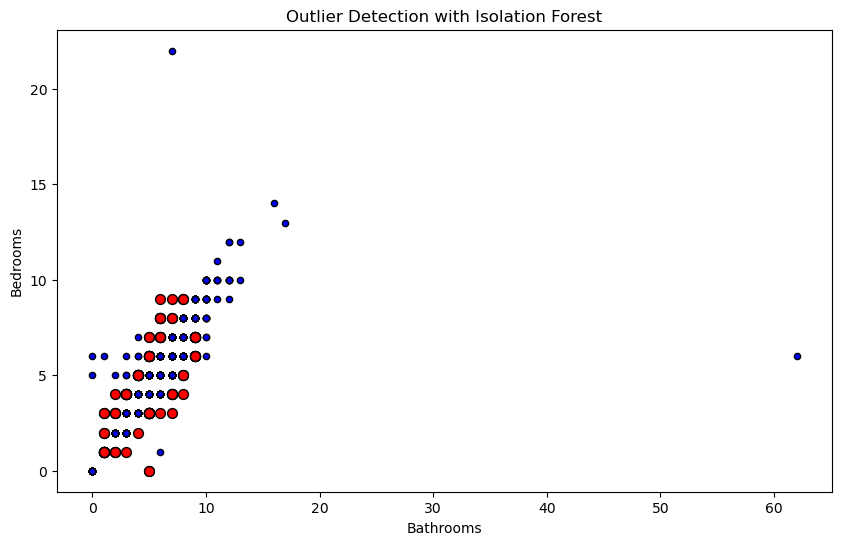

In [93]:
plt.figure(figsize=(10, 6))
plt.scatter(temp_houses.loc[~is_outlier, 'Bathrooms'], temp_houses.loc[~is_outlier, 'Bedrooms'], color='b', s=20, edgecolor='k')

# Highlighting the outliers
is_outlier = y_pred == -1
plt.scatter(temp_houses.loc[is_outlier, 'Bathrooms'], temp_houses.loc[is_outlier, 'Bedrooms'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bathrooms")
plt.ylabel("Bedrooms")
plt.show()

In [147]:
# Filling values where Bedrooms or Bathrooms == 0

zero_bed = houses[houses['Bedrooms']==0].index

zero_bath = houses[houses['Bathrooms']==0].index

In [148]:
houses.loc[zero_bath,'Bathrooms'] = houses.loc[zero_bath,'Bath(s)']
houses.loc[zero_bed,'Bedrooms'] = houses.loc[zero_bed,'Bedroom(s)']

In [149]:
houses['BedBath_Diff'] = houses['Bedrooms'] - houses['Bathrooms']

In [154]:
outlier_rows = houses[(houses['BedBath_Diff']>2)|(houses['BedBath_Diff']<-2)]

In [155]:
outlier_rows.shape

(32, 29)

In [156]:
outlier_rows[['Price(Cr)', 'Bath(s)', 'Bathrooms','Area(Marla)', 'Bedroom(s)','Bedrooms']]

,Price(Cr),Bath(s),Bathrooms,Area(Marla),Bedroom(s),Bedrooms
18,14.50,7.0,6.0,16.0,6.0,1.0
95,140.00,6.0,4.0,58.0,7.0,7.0
110,22.00,6.0,9.0,26.0,6.0,6.0
506,11.65,7.0,3.0,20.0,6.0,6.0
566,5.50,6.0,10.0,10.0,7.0,6.0
581,3.95,5.0,8.0,7.0,4.0,5.0
593,39.00,6.0,9.0,40.0,6.0,6.0
635,11.95,8.0,8.0,20.0,5.0,5.0
849,16.50,7.0,7.0,40.0,7.0,3.0
947,4.00,7.0,7.0,7.0,5.0,4.0


In [157]:
houses['Description'].loc[95]

"Details: 1. Size 1466 sqyrds+ kanals Additional Land 2. Margla & Sunfacing. 3. Side and Front open to Green belt. 4. Convienient approaches from Margla Road, Kohsar Road and Parbat Road. 5. Accomodation; It's a farm house within the downtown. The house has a huge lush green lawn at its back and Side. all the windows of all the three floors have magnificent Margla views all around. The house has been built as per the international standards of architecture for luxury and comfort. It has 7 bed rooms, 3 lounges, D+D, one main kitchen, on ground along with greecy kitchen. long drive ways, central heating and cooling systems. 6. Single owner. 7. possession Available 8. Price 140 crs."

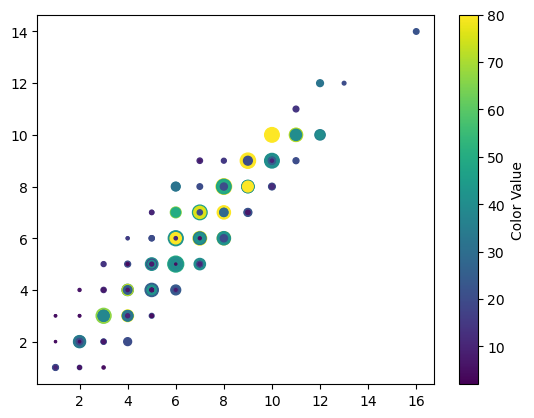

In [158]:
scatter = plt.scatter(data=houses.drop(index=outlier_rows.index),x='Bathrooms',y='Bedrooms',s='Price(Cr)',c='Area(Marla)',cmap='viridis')
plt.colorbar(scatter, label='Color Value')

In [159]:
outlier_rows.index

Index([  18,   95,  110,  506,  566,  581,  593,  635,  849,  947, 1036, 1065,
       1106, 1197, 1211, 1254, 1344, 1624, 1698, 1857, 1892, 1910, 1911, 1973,
       1988, 2378, 2610, 2632, 2646, 2688, 2735, 2796],
      dtype='int64')

In [160]:
# Removing the outliers rows

houses.drop(outlier_rows.index,inplace=True)

In [162]:
houses.shape

(2029, 29)

In [163]:
houses.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Storey Unit',
       'BedBath_Diff'],
      dtype='str')

In [164]:
# Built in Year

In [165]:
houses['Built in year'].value_counts()

Built in year
2025.0     807
0.0        372
2024.0     254
1.0        127
2023.0     104
2020.0      47
2022.0      41
2015.0      30
2021.0      30
2018.0      24
2010.0      22
2019.0      19
2000.0      18
2017.0      13
2016.0      12
1990.0      10
2026.0       9
2005.0       9
2.0          8
2012.0       8
1998.0       6
1999.0       5
2014.0       5
2027.0       4
2009.0       4
2001.0       3
10.0         3
2002.0       3
20223.0      2
2013.0       2
2008.0       2
225.0        2
2028.0       2
4.0          1
1997.0       1
2250.0       1
1970.0       1
15.0         1
2050.0       1
40.0         1
5.0          1
1996.0       1
2003.0       1
2004.0       1
1978.0       1
20000.0      1
205.0        1
20242.0      1
3.0          1
1995.0       1
1898.0       1
2007.0       1
1965.0       1
7.0          1
1987.0       1
Name: count, dtype: int64

In [166]:
houses[houses['Built in year']==2050]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
537,House,4.2,7.0,7.0,5.0,Gulberg,Block F Near to park 5 bad 7 bath 2 lounge 2 k...,"Built in year: 2050, Parking Spaces: 3, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,3.0,3.0,6.0,7.0,1.0,2.0,1.0,1.0,NaN,-1.0


In [169]:
# There are many Errors, need to correct them manually

year_errors = {
    20242:2024,
    20223:2023,
    225:2025,
    2250:2025,
    2050:2025,
    20000:2000,
    205:2025,
    20242:2024
}

houses['Built in year'] = houses['Built in year'].replace(year_errors)

*Changing the Built in year of Brand New Houses to 2025*

In [196]:
newHouses = houses[(houses['Built in year']< 1800)&(houses['Description'].str.lower().str.contains('brand new'))].index

In [197]:
newHouses 

Index([   0,    6,    8,   34,   35,   44,   49,   50,   67,  161,
       ...
       2542, 2595, 2650, 2701, 2731, 2762, 2763, 2777, 2848, 2852],
      dtype='int64', length=115)

In [198]:
houses.loc[newHouses,'Built in year'] = 2025

*Changing the value to Nan where Built in year is misleading (e.g where there is values less than 1800)*

In [207]:
Nanyear = houses[houses['Built in year']<1800].index

houses.loc[Nanyear,'Built in year'] = np.nan

In [209]:
houses['Built in year'].value_counts()

Built in year
2025.0    927
2024.0    255
2023.0    106
2020.0     47
2022.0     41
2015.0     30
2021.0     30
2018.0     24
2010.0     22
2019.0     19
2000.0     19
2017.0     13
2016.0     12
1990.0     10
2026.0      9
2005.0      9
2012.0      8
1998.0      6
1999.0      5
2014.0      5
2027.0      4
2009.0      4
2001.0      3
2002.0      3
2013.0      2
2008.0      2
2028.0      2
1997.0      1
1970.0      1
1996.0      1
2003.0      1
2004.0      1
1978.0      1
1995.0      1
1898.0      1
2007.0      1
1965.0      1
1987.0      1
Name: count, dtype: int64

In [210]:
houses.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Storey Unit',
       'BedBath_Diff'],
      dtype='str')

In [211]:
# Parking Spaces

<Axes: xlabel='Parking Spaces', ylabel='count'>

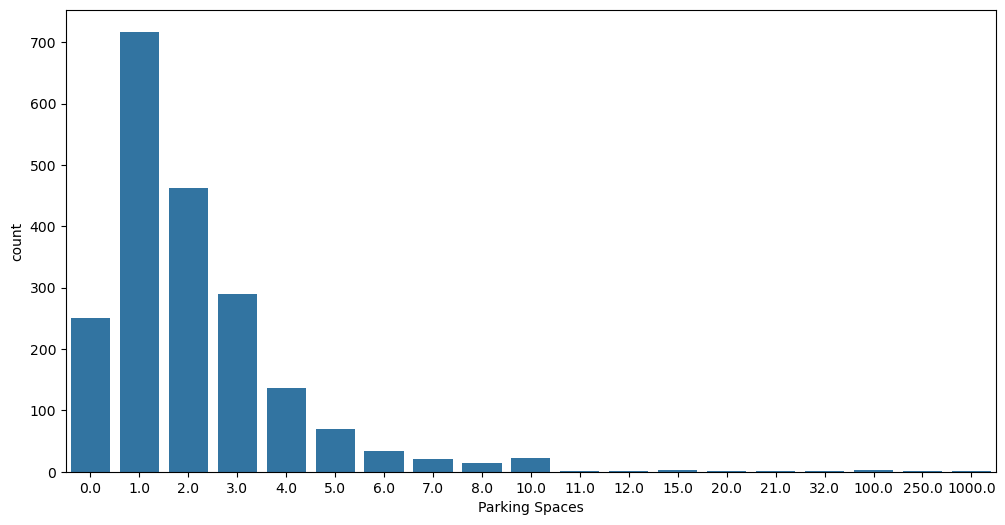

In [214]:
plt.figure(figsize=(12,6))
sns.barplot(houses['Parking Spaces'].value_counts())

In [215]:
houses['Parking Spaces'].value_counts()

Parking Spaces
1.0       717
2.0       463
3.0       290
0.0       250
4.0       137
5.0        69
6.0        33
10.0       23
7.0        20
8.0        15
15.0        3
100.0       2
20.0        1
11.0        1
21.0        1
250.0       1
32.0        1
1000.0      1
12.0        1
Name: count, dtype: int64

In [219]:
houses[houses['Parking Spaces']>=5]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
37,House,19.0,7.0,20.0,9.0,F-11,Corner House For Sale 50/90 Triple Story Prime...,"Built in year: 1998, Parking Spaces: 6, Double...","Bedrooms: 9, Bathrooms: 10, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,9.0,10.0,1.0,2.0,1.0,1.0,3.0,-1.0
41,House,19.0,6.0,24.0,8.0,G-10,outstanding location Beautiful House 60/90 600...,"Built in year: 1997, Parking Spaces: 6, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,8.0,8.0,2.0,2.0,2.0,1.0,3.0,0.0
69,House,26.5,6.0,20.0,7.0,D-12,Luxurious 3-Story Kanal House for Sale Key Fea...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,7.0,7.0,1.0,2.0,1.0,NaN,3.0,0.0
94,House,58.0,6.0,38.0,5.0,E-7,Details; 1. Size 80 x 105 : 975 sqyrds. 2. Sun...,"Built in year: 1990, Parking Spaces: 10, Doubl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,10.0,2.0,5.0,6.0,2.0,1.0,1.0,1.0,1.0,-1.0
112,House,10.0,5.0,20.0,5.0,DHA Defence,We offer you just the right House to purchase....,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,5.0,5.0,2.0,2.0,2.0,1.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2832,House,65.0,3.0,38.0,3.0,E-7,When you have a property of 933 Square Yards w...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,6.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,NaN,0.0
2838,House,65.0,11.0,40.0,10.0,F-7,Details: 1. Size 100 x 90 = 1000 sqyrds. 2. su...,"Parking Spaces: 6, Double Glazed Windows, Cent...","Bedrooms: 10, Bathrooms: 11, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,6.0,3.0,10.0,11.0,2.0,2.0,2.0,NaN,NaN,-1.0
2843,House,30.0,6.0,40.0,10.0,F-8,Indulge In Grandeur With This Majestic 10-Bedr...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,5.0,6.0,2.0,3.0,1.0,NaN,NaN,-1.0
2853,House,34.0,8.0,28.0,7.0,F-7,house available for sale in f7 demoliable hous...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,5.0,2.0,7.0,8.0,2.0,2.0,1.0,1.0,NaN,-1.0


<Axes: xlabel='Area(Marla)', ylabel='Parking Spaces'>

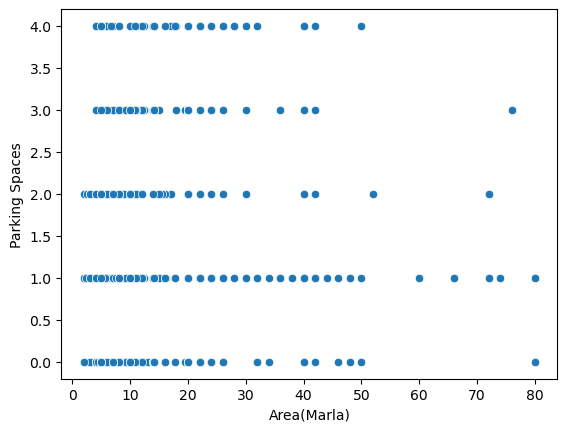

In [222]:
sns.scatterplot(houses[houses['Parking Spaces']<=4],x='Area(Marla)',y='Parking Spaces')

*By looking at this chart, we can deduce that the Parking Space column is misleading even though it looks useful.*

The reason could be human error, the agent exaggerated this feature.

**So the best thing is to drop it to avoid any error in the model**

In [225]:
# Floor and Storey Unit

*Storey Unit is more reliable because we directly extracted from the description column.*

### What to do:

1. Use Storey Unit as the Floor column
2. And use Floor column where Storey Unit information is missing.

<Axes: xlabel='Floor', ylabel='count'>

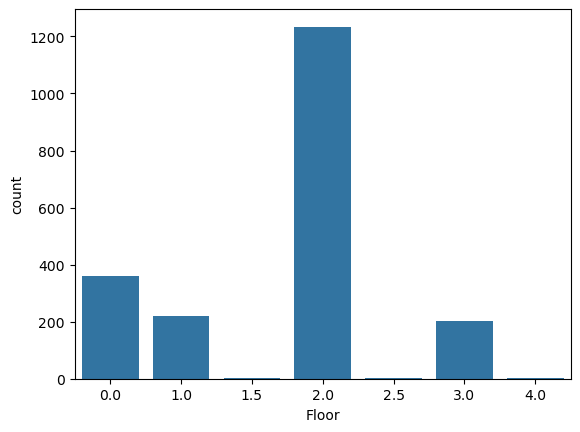

In [224]:
sns.barplot(houses['Floor'].value_counts())

<Axes: xlabel='Storey Unit', ylabel='count'>

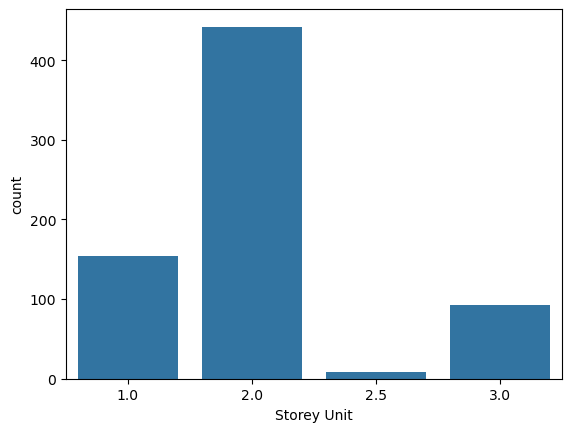

In [226]:
sns.barplot(houses['Storey Unit'].value_counts())

In [229]:
Nanstorey = houses['Storey Unit'].isnull()[houses['Storey Unit'].isnull()==True].index

In [231]:
houses.loc[Nanstorey,'Storey Unit'] = houses.loc[Nanstorey,'Floor']

<Axes: xlabel='Storey Unit', ylabel='count'>

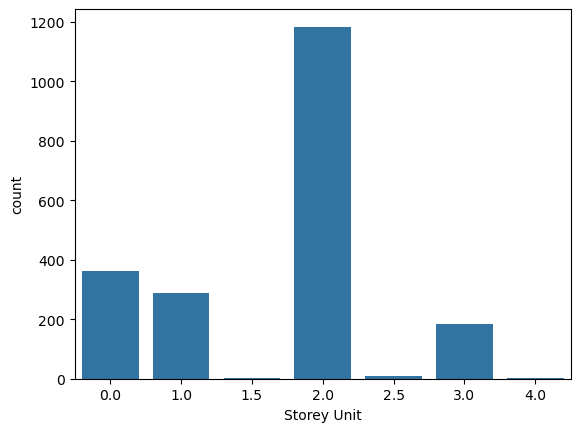

In [232]:
sns.barplot(houses['Storey Unit'].value_counts())

*Setting the Storey Unit==0 as Nan value*

In [234]:
zero_storey = houses[houses['Storey Unit']==0].index

In [235]:
houses.loc[zero_storey,'Storey Unit'] = np.nan

In [236]:
# Servant Quarter

In [240]:
houses['Servant Quarters'].value_counts()

Servant Quarters
1.0     970
2.0     410
0.0     177
3.0      23
4.0       5
8.0       3
6.0       2
12.0      2
5.0       2
22.0      1
7.0       1
Name: count, dtype: int64

<Axes: xlabel='Servant Quarters', ylabel='count'>

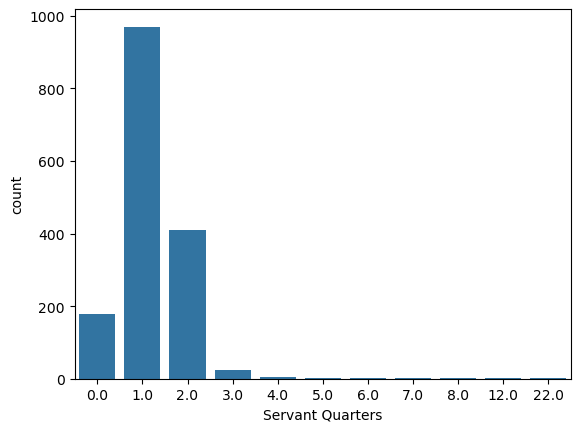

In [239]:
sns.barplot(houses['Servant Quarters'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [243]:
Nanservantquar = houses[~houses['Servant Quarters'].isin([1,2])].index

In [246]:
houses.loc[Nanservantquar,'Servant Quarters'] = np.nan

In [247]:
# Store Rooms

<Axes: xlabel='Store Rooms', ylabel='count'>

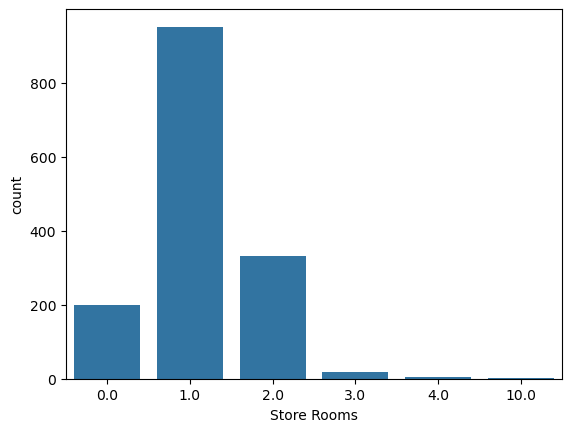

In [248]:
sns.barplot(houses['Store Rooms'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [251]:
Nanstore = houses[~houses['Store Rooms'].isin([1,2,3])].index

In [253]:
houses.loc[Nanstore,'Store Rooms'] = np.nan

In [254]:
# Kitchens 

<Axes: xlabel='Kitchens', ylabel='count'>

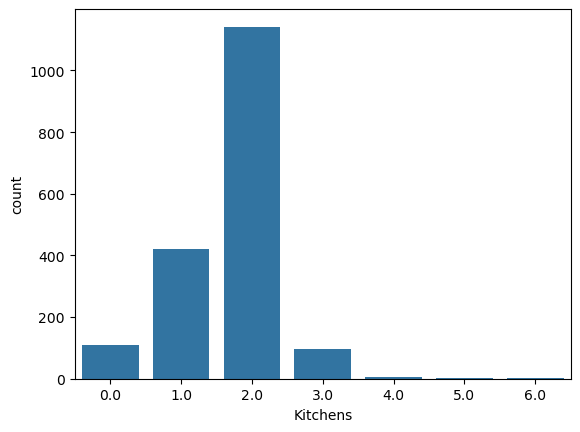

In [256]:
sns.barplot(houses['Kitchens'].value_counts())

In [258]:
houses[houses['Kitchens']>3].index

Index([456, 545, 977, 2142, 2716, 2729, 2794, 2865], dtype='int64')

In [275]:
houses.loc[2865]

Type                                                                                 House
Price(Cr)                                                                             16.0
Bath(s)                                                                               16.0
Area(Marla)                                                                           22.0
Bedroom(s)                                                                            14.0
Location                                                                              G-11
Description                              Kanal+ Big and Elegant House is available for ...
Amenities: Main Features                 Built in year: 2025, Parking Spaces: 6, Floori...
Amenities: Rooms                         Bedrooms: 14, Bathrooms: 16, Servant Quarters:...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features             Community Lawn or Garden, Kids Play Area, Mosque

In [276]:
houses['Description'].loc[2865]

'Kanal+ Big and Elegant House is available for Sale in G11 Islamabad Size 60x90 14 Bedrooms 16 Washrooms 6 Drwaing Dinings 6 TVLs 6 Kitchens 3 Gates 4 Gas Meters 4 Electric Meters Ample parking space Corner with extra land and basement Wide streets Near by Masjid and Market CDA Transfer P. S. : Pictures are real'

*Upon further analyzing, Kitchens > 3 doesn't seems outlier, so we will keep them*

*However changing the Kitchens = 0 to Nan*

In [280]:
Nankitchens = houses[~houses['Kitchens'].isin([1,2])].index

In [281]:
houses.loc[Nankitchens,'Kitchens'] = np.nan

In [278]:
houses.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Storey Unit',
       'BedBath_Diff'],
      dtype='str')

In [282]:
# Saving the file

In [283]:
houses.to_csv('houses_outlier_handled.csv')